In [38]:
import pandas as pd
df=pd.read_csv("https://raw.githubusercontent.com/Saranmanoharan511/customer-propensity-model/main/customer-propensity-model/final_dataset.zip", compression="zip")
df.head()



,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,AvgPurchaseInterval,Target
0,12346.0,326,1,77183.60,77183.600000,0.0,0.0
1,12347.0,2,182,4310.00,23.681319,2.0,1.0
2,12348.0,75,31,1797.24,57.975484,9.4,0.0
3,12349.0,19,73,1757.55,24.076027,0.0,1.0
4,12350.0,310,17,334.40,19.670588,0.0,0.0


In [39]:
X=df.drop(["CustomerID","Target"],axis=1)
y=df["Target"]

In [40]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)



In [41]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [42]:
from xgboost import XGBClassifier
model=XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [43]:
y_pred=model.predict(X_test)
y_scores=model.predict_proba(X_test)[:,1]


In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       528
         1.0       1.00      1.00      1.00       340

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



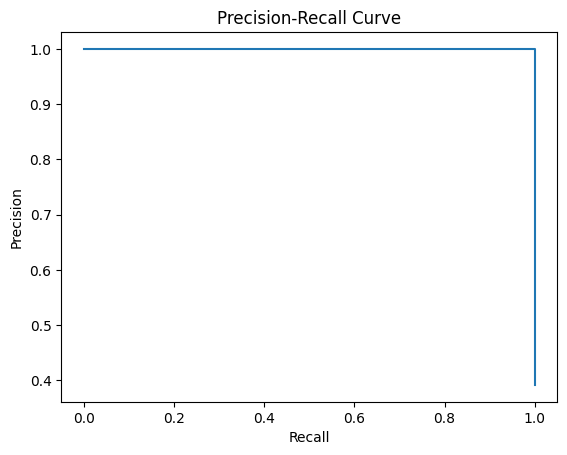

In [45]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [46]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

               Feature  Importance
0              Recency         1.0
1            Frequency         0.0
2             Monetary         0.0
3        AvgOrderValue         0.0
4  AvgPurchaseInterval         0.0
